# Makemore Exercises. Part II

So I have watched videos 3 and 4 of Andrey Karapthy course, and decided to try beat Karpathy 2.1 validation loss using PyTorch's API (i.e. use ADAM, BatchNorm etc) and hyperparameter (naive) optimization

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [38]:
words = open('data/names.txt', 'r').read().splitlines()

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

# encoder: take a string, output a list of integers
encode = lambda s: [stoi[c] for c in s]
# decoder: take a list of integers, output a string
decode = lambda l: ''.join([itos[i] for i in l])

In [3]:
from torch.utils.data import Dataset, DataLoader
class NgrammDataset(Dataset):
    def __init__(self, words, stoi, context_length = 1):
      X, Y = [], []
      for w in words:
          context = [0] * context_length
          for ch in w + '.':
              ix = stoi[ch]
              X.append(context)
              Y.append(ix)
              context = context[1:] + [ix] # crop and append
      self.ngramms = torch.tensor(X)
      self.nextchars = torch.tensor(Y)

    def __len__(self):
        return self.ngramms.shape[0]

    def __getitem__(self, idx):
        return self.ngramms[idx], self.nextchars[idx]

In [4]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

In [5]:
class NGramEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim = None, context_size = None):
        super(NGramEmbedding, self).__init__()
        self.output_dim = context_size * embedding_dim
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
      
    def forward(self, inputs):
        embeds = self.embeddings(inputs).view(-1, self.output_dim)
        return embeds


In [30]:
from tqdm import tqdm
import itertools 

results = []
hypers = itertools.product([4, 8], [2,4,6], [(20, 20), (40, 40), (60, 60)], [0.001, 0.005, 0.1])
for context_size, embedding_dim, hidden_sizes, lr in tqdm(hypers):
  train_dataset = NgrammDataset(words[:n1], stoi, context_length = context_size)
  valid_dataset = NgrammDataset(words[n1:n2], stoi, context_length = context_size)
  train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
  valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

  hidden_l1_size, hidden_l2_size = hidden_sizes

  model = nn.Sequential(
    NGramEmbedding(VOCAB_SIZE, embedding_dim = embedding_dim, context_size = context_size),
    nn.Linear(embedding_dim * context_size, hidden_l1_size),
    nn.BatchNorm1d(hidden_l1_size, momentum = 0.05),
    nn.Tanh(),
    nn.Linear(hidden_l1_size, hidden_l2_size),
    nn.BatchNorm1d(hidden_l2_size, momentum = 0.05),
    nn.Tanh(),
    nn.Linear(hidden_l2_size, VOCAB_SIZE),
    nn.LogSoftmax(dim = 1)
  )
  model.train()
  loss_function = nn.NLLLoss()
  optimizer = optim.AdamW(model.parameters(), lr = lr)
  for epoch in range(20):
    for data, target in train_dataloader:
      optimizer.zero_grad()
      log_probs = model(data)
      loss = loss_function(log_probs, target) 
      loss.backward()
      optimizer.step()
  model.eval()
  # compute train loss
  log_probs = model(train_dataset.ngramms)
  loss_train = -log_probs[torch.arange(train_dataset.nextchars.shape[0]), train_dataset.nextchars].mean().item()
  # computre validation loss
  log_probs = model(valid_dataset.ngramms)
  loss_valid = -log_probs[torch.arange(valid_dataset.nextchars.shape[0]), valid_dataset.nextchars].mean().item()
  
  results.append({
    "embedding_dim" : embedding_dim,
    "context_size"  : context_size,
    "hidden_l1_size" : hidden_l1_size,
    "hidden_l2_size" : hidden_l2_size,
    "lr": lr,
    "loss_train": loss_train,
    "loss_valid": loss_valid
  })

54it [30:07, 33.48s/it]


In [31]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df.sort_values('loss_valid')

,embedding_dim,context_size,hidden_l1_size,hidden_l2_size,lr,loss_train,loss_valid
52,6,8,60,60,0.005,2.042873,2.087215
51,6,8,60,60,0.001,2.065246,2.104923
42,4,8,60,60,0.001,2.081126,2.112530
43,4,8,60,60,0.005,2.079042,2.118093
24,6,4,60,60,0.001,2.094753,2.123748
25,6,4,60,60,0.005,2.087709,2.132868
48,6,8,40,40,0.001,2.108824,2.135033
49,6,8,40,40,0.005,2.106356,2.136119
40,4,8,40,40,0.005,2.114021,2.142035
16,4,4,60,60,0.005,2.116728,2.142385


So far, best choice for hyperparams is:

In [32]:
hyperparams = results_df.iloc[52].drop(['loss_valid', 'loss_train'])
hyperparams

embedding_dim      6.000
context_size       8.000
hidden_l1_size    60.000
hidden_l2_size    60.000
lr                 0.005
Name: 52, dtype: float64

In [33]:
hyperparams = {
  "embedding_dim"  :  6,
  "context_size"   :  8,
  "hidden_l1_size" :  60,
  "hidden_l2_size" :  60,
  "lr"             :  0.005
}

In [35]:
model = nn.Sequential(
          NGramEmbedding(VOCAB_SIZE, embedding_dim = hyperparams['embedding_dim'], context_size = hyperparams['context_size']),
          nn.Linear(hyperparams['embedding_dim'] * hyperparams['context_size'], hyperparams['hidden_l1_size']),
          nn.BatchNorm1d(hyperparams['hidden_l1_size'], momentum = 0.05),
          nn.Tanh(),
          nn.Linear(hyperparams['hidden_l1_size'], hyperparams['hidden_l2_size']),
          nn.BatchNorm1d(hyperparams['hidden_l2_size'], momentum = 0.05),
          nn.Tanh(),
          nn.Linear(hyperparams['hidden_l2_size'], VOCAB_SIZE),
          nn.LogSoftmax(dim = 1)
        )

loss_function = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr = hyperparams['lr'])
losses_train = []
losses_valid = []
for epoch in range(100):
  model.train()
  for data, target in train_dataloader:
    optimizer.zero_grad()
    log_probs = model(data)
    loss = loss_function(log_probs, target) 
    loss.backward()
    optimizer.step()

  model.eval()
  # compute train loss
  log_probs = model(train_dataset.ngramms)
  losses_train.append(-log_probs[torch.arange(train_dataset.nextchars.shape[0]), train_dataset.nextchars].mean().item())
  # computre validation loss
  log_probs = model(valid_dataset.ngramms)
  losses_valid.append(-log_probs[torch.arange(valid_dataset.nextchars.shape[0]), valid_dataset.nextchars].mean().item())
 

2.0932748317718506


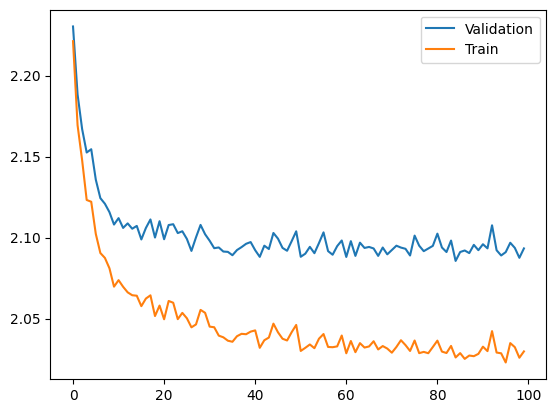

In [36]:
import matplotlib.pyplot as plt
plt.plot(range(len(losses_valid)), losses_valid, label = "Validation")
plt.plot(range(len(losses_train)), losses_train, label = "Train")
plt.legend()
print(losses_valid[-1])

Success!

In [65]:
def generate(model, sampler, **kwargs):
  model.eval()
  context = [0]*context_size
  output_ = []
  while True:
    nextchar = sampler(model(torch.tensor(context)), **kwargs)
    context = context[1:] + [nextchar]
    if nextchar == 0:
      break
    output_.append(decode([nextchar]))
  return ''.join(output_)

In [66]:
def random_sampler(log_probs, generator = torch.Generator().manual_seed(1)):
  return torch.multinomial(log_probs.exp(), num_samples=1, replacement = True, generator = generator).item()

In [69]:
generator = torch.Generator().manual_seed(12345)
for i in range(10):
  print(generate(model, random_sampler, generator = generator))

amilee
morius
meidone
ayanzleeus
anitveia
tadaya
wam
shayah
shaiden
henodion
